In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [16]:
from langsmith import Client
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import TextLoader
from langchain_teddynote.callbacks import StreamingCallback

In [6]:
loader = TextLoader("../data/news.txt",encoding="utf-8")
docs = loader.load()

In [3]:
map_llm = ChatOpenAI(
    temperature=0,
    model="gpt-4o-mini"
)

clinet = Client()
map_summary = clinet.pull_prompt(
    "teddynote/map-summary-prompt",
    dangerously_pull_public_prompt=True
)

map_summary.pretty_print()

================================ System Message ================================

You are an expert summarizer. Your task is to summarize the following document in {language}.

================================ Human Message =================================

Extract most important main thesis from the documents, then summarize in bullet points.

#Format:
- summary 1
- summary 2
- summary 3
-...

Here is a given document: 
{documents}

Write 1~5 sentences. Think step by step.
#Summary:


In [8]:
map_chain = map_summary | map_llm | StrOutputParser()

In [11]:
print(map_chain.invoke({"documents": docs[0], "language": "Korean"}))

- 앨런AI연구소(AI2)가 완전한 오픈 소스 대형언어모델(LLM) '올모(OLMo)'를 출시하여 상업적 사용이 가능하다는 점에서 진정한 오픈 소스 모델로 평가받고 있다.
- 올모는 모델 코드, 가중치, 훈련 데이터 및 관련 툴킷을 포함하여 모델의 작동 원리를 깊이 이해할 수 있도록 설계되었다.
- 70억 매개변수의 '올모 7B'와 10억 매개변수의 '올모 1B' 등 다양한 변형 모델이 제공되며, 훈련 데이터는 AI2의 '돌마(Dolma)' 데이터 세트를 기반으로 한다.
- 올모는 상업적 활용에 제한이 없으며, 성능 면에서도 기존 상업용 제품과 동등한 수준을 보여준다.
- AI2는 올모의 출식을 통해 AI 모델에 대한 깊은 이해를 위한 기반을 마련하고, 오픈 소스 커뮤니티의 중요성을 강조하고 있다.


In [20]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("../data/SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()
docs = docs[3:8]

In [21]:
input_doc = [{"documents": doc, "language": "Korean"} for doc in docs]
input_doc

[{'documents': Document(metadata={'producer': 'Hancom PDF 1.3.0.542', 'creator': 'Hwp 2018 10.0.0.13462', 'creationdate': '2023-12-08T13:28:38+09:00', 'author': 'dj', 'moddate': '2023-12-08T13:28:38+09:00', 'pdfversion': '1.4', 'source': '../data/SPRI_AI_Brief_2023년12월호_F.pdf', 'total_pages': 23, 'page': 3, 'page_label': '4'}, page_content='1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육\n미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표 \nn 미국 바이든 대통령이 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명하고 \n광범위한 행정 조치를 명시\nn 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 \n보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함\nKEY Contents\n£ 바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진\nn 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과 \n사용을 보장하기 위한 행정명령을 발표\n∙ 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 보호 \n△노동자 지원 △혁신과 경쟁 촉진 △국제협력에 관한 내용을 포괄\nn (AI 안전과 보안 기준) 강력한 AI 시스템을 개발하는 기업에게 안전 테스트 결과와 시스템에 관한 \n주요 정보를 미국 정부와 공유할 것을 요구하고, AI 시스템의 안전성과 신뢰성 확인을 위한 표준 및 \nAI 생성 콘텐츠 표시를 위한 표준과 모범사례 확립을 추진\n∙ △1026 플롭스(FLOPS, F

In [22]:
print(map_chain.batch(input_doc))

['- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 위한 행정명령을 발표하였다.\n- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제 협력을 포함한다.\n- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 지침이 마련된다.\n- 소비자 보호와 근로자 지원을 위해 의료 분야에서의 AI 사용 촉진 및 교육 도구 개발이 강조된다.\n- 국가 AI 연구자원(NAIRR)을 통해 AI 연구를 촉진하고, 외국인 전문가의 미국 내 학습과 취업을 지원하는 방안도 포함된다.', "- G7은 2023년 10월 30일 '히로시마 AI 프로세스'를 통해 AI 기업을 위한 국제 행동강령에 합의하였다.\n- 이 행동강령은 AI 시스템의 위험 식별 및 완화를 위한 자발적인 채택을 권장하며, AI 수명주기 전반에 걸친 위험 평가와 투명성, 책임성을 강조한다.\n- 주요 내용으로는 정보 공유, 보안 통제, 콘텐츠 인증 및 출처 확인 메커니즘 개발 등이 포함된다.\n- G7은 기술 발전에 대응하기 위해 이해관계자 간 협의를 통해 행동강령을 필요에 따라 개정할 예정이다.\n- 또한, 사회적 위험 완화와 글로벌 문제 해결을 위한 AI 시스템 개발을 우선시하고, 개인정보 보호를 위한 적절한 보호 장치를 구현할 것을 요구하고 있다.", '- 28개국이 영국 블레츨리 파크에서 열린 AI 안전성 정상회의에서 AI 안전 보장을 위한 블레츨리 선언을 발표했다.\n- 선언은 AI 시스템의 안전성을 보장하기 위해 모든 이해관계자의 협력이 필요하다고 강조하며, 특히 AI 개발 기업의 책임을 지적했다.\n- 영국 총리는 AI 안전 연구소의 출범과 함께 첨단 AI 모델에 대한 안전성 시험 계획을 발표하고, 각국 정부는 테스트 결과를 공유하기로 합의했다.\n- 참가국들은 AI 위험과 가능성에 대한 과학적 평가를 위한 보고서 작성을 합의하고, 한국은 

In [23]:
refine_prompt = clinet.pull_prompt(
    "teddynote/refine-prompt",
    dangerously_pull_public_prompt=True
)

refine_prompt.pretty_print()

================================ System Message ================================

You are an expert summarizer.

================================ Human Message =================================

Your job is to produce a final summary

We have provided an existing summary up to a certain point:
{previous_summary}

We have the opportunity to refine the existing summary(only if needed) with some more context below.
------------
{current_summary}
------------
Given the new context, refine the original summary in {language}.
If the context isn't useful, return the original summary.


In [24]:
refine_llm = ChatOpenAI(
    temperature=0,
    model="gpt-4o-mini"
)

refine_chain = refine_prompt | refine_llm | StrOutputParser()

In [25]:
from langchain_core.runnables import chain

@chain
def map_refine_chain(docs):
    map_summary = clinet.pull_prompt(
        "teddynote/map-summary-prompt",
        dangerously_pull_public_prompt=True,
    )

    map_chain = (
        map_summary
        | ChatOpenAI(
            model="gpt-4o-mini",
            temperature=0,
        )
        | StrOutputParser()
    )

    input_doc = [{"documents": doc.page_content, "language": "Korean"} for doc in docs]

    doc_summaries = map_chain.batch(input_doc)

    refine_prompt = clinet.pull_prompt(
        "teddynote/refine-prompt",
        dangerously_pull_public_prompt=True,
    )

    refine_llm = ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0,
        callbacks=[StreamingCallback()],
        streaming=True,
    )

    refine_chain = refine_prompt | refine_llm | StrOutputParser()

    previous_summary = doc_summaries[0]

    for current_summary in doc_summaries[1:]:

        previous_summary = refine_chain.invoke(
            {
                "previous_summary": previous_summary,
                "current_summary": current_summary,
                "language": "Korean",
            }
        )
        print("\n\n--------------------\n\n")

    return previous_summary    

In [26]:
refined_summary = map_refine_chain.invoke(docs)

- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 위한 행정명령을 발표하였다.
- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제 협력을 포함한다.
- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 모범사례와 지침이 마련된다.
- 소비자 보호와 근로자 지원을 위해 의료 분야에서의 AI 사용 촉진 및 교육 도구 개발이 강조된다.
- 국가 AI 연구 자원을 통해 AI 연구를 촉진하고, 외국인 전문가들이 미국에서 공부하고 일할 수 있도록 지원하는 방안도 포함된다.
- 또한, G7은 '히로시마 AI 프로세스'를 통해 AI 기업을 위한 국제 행동강령에 합의하였으며, 이는 AI 시스템의 위험 식별 및 완화를 위한 자발적 채택을 권장하고, 위험 평가와 투명성, 책임성을 강조한다. 
- G7은 AI 기술의 빠른 발전에 대응하기 위해 행동강령을 지속적으로 개정하고, 사회적 위험 완화와 글로벌 문제 해결을 위한 AI 시스템 개발에 우선 투자할 계획이다.

--------------------


- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 위한 행정명령을 발표하였다.
- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제 협력을 포함한다.
- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 모범사례와 지침이 마련된다.
- 소비자 보호와 근로자 지원을 위해 의료 분야에서의 AI 사용 촉진 및 교육 도구 개발이 강조된다.
- 국가 AI 연구 자원을 통해 AI 연구를 촉진하고, 외국인 전문가들이 미국에서 공부하고 일할 수 있도록 지원하는 방안도 포함된다.
- G7은 '히로시마 AI 프로세스'를 통해 AI 기업을 위한 국제 행동강령에 합의하였으며,

In [29]:
from langchain_community.document_loaders import PyMuPDFLoader

loader = PyMuPDFLoader("../data/SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()
len(docs)

23

In [30]:
texts = "\n\n".join([doc.page_content for doc in docs])
len(texts)

27977

In [31]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
split_docs = text_splitter.split_text(texts)

In [32]:
len(split_docs)

79

In [33]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings()

vectors = embeddings.embed_documents(split_docs)

In [34]:
from sklearn.cluster import KMeans

num_clusters = 10

kmenas = KMeans(n_clusters=num_clusters, random_state=123).fit(vectors)

In [35]:
kmenas.labels_

array([3, 1, 1, 5, 0, 8, 8, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3,
       7, 3, 7, 7, 7, 7, 4, 4, 4, 4, 9, 9, 9, 1, 2, 2, 2, 2, 5, 5, 5, 0,
       3, 0, 0, 5, 5, 5, 5, 0, 0, 0, 5, 0, 0, 0, 0, 3, 3, 3, 1, 1, 1, 1,
       5, 0, 0, 5, 6, 6, 6, 8, 0, 8, 8, 8, 3], dtype=int32)

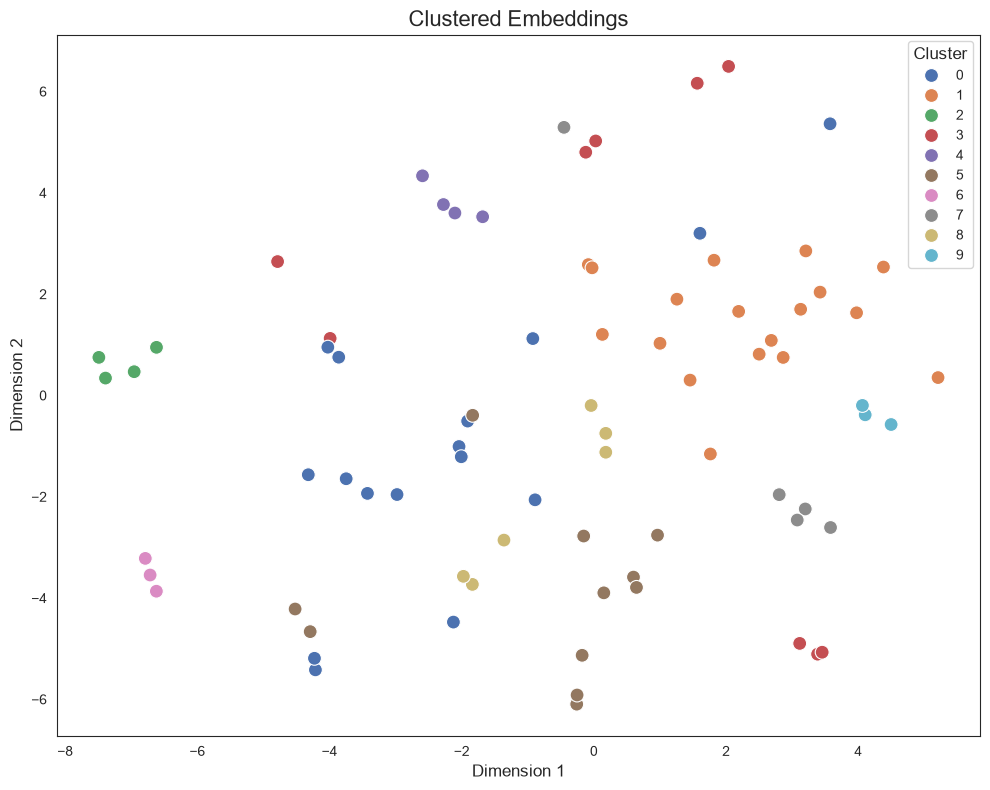

In [36]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings("ignore")

tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(np.array(vectors))

sns.set_style("white")

plt.figure(figsize=(10,8))
sns.scatterplot(
    x = reduced_data_tsne[:, 0],
    y = reduced_data_tsne[:, 1],
    hue = kmenas.labels_,
    palette = "deep",
    s = 100,
)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)
plt.title("Clustered Embeddings", fontsize=16)
plt.legend(title="Cluster", title_fontsize=12)

plt.gcf().patch.set_facecolor("white")

plt.tight_layout()
plt.show()

In [37]:
closest_indices = []

for i in range(num_clusters):
    distances = np.linalg.norm(vectors - kmenas.cluster_centers_[i], axis=1)

    closest_index = np.argmin(distances)

    closest_indices.append(closest_index)

In [38]:
closest_indices

[np.int64(55),
 np.int64(17),
 np.int64(37),
 np.int64(59),
 np.int64(29),
 np.int64(3),
 np.int64(70),
 np.int64(25),
 np.int64(5),
 np.int64(32)]

In [39]:
selected_indices = sorted(closest_indices)
selected_indices

[np.int64(3),
 np.int64(5),
 np.int64(17),
 np.int64(25),
 np.int64(29),
 np.int64(32),
 np.int64(37),
 np.int64(55),
 np.int64(59),
 np.int64(70)]

In [40]:
from langchain_core.documents import Document

selected_docs = [Document(page_content=split_docs[doc]) for doc in selected_indices]
selected_docs

[Document(metadata={}, page_content='▹ 알리바바 클라우드, 최신 LLM ‘통이치엔원 2.0’ 공개 ······················································ 9\n   ▹ 삼성전자, 자체 개발 생성 AI ‘삼성 가우스’ 공개 ··························································· 10\n   ▹ 구글, 앤스로픽에 20억 달러 투자로 생성 AI 협력 강화 ················································ 11\n   ▹ IDC, 2027년 AI 소프트웨어 매출 2,500억 달러 돌파 전망··········································· 12\n   ▹ 빌 게이츠, AI 에이전트로 인한 컴퓨터 사용의 패러다임 변화 전망································ 13'),
 Document(metadata={}, page_content='4. 인력/교육     \n   ▹ 영국 옥스퍼드 인터넷 연구소, AI 기술자의 임금이 평균 21% 높아······························· 18\n   \n   \n \nⅡ. 주요 행사\n   ▹CES 2024 ····························································································································· 19\n   ▹AIMLA 2024 ························································································································· 19'),
 Document(metadata={}, page_content='∙선언은 AI 안전 보장을 위해 국가, 국제기구, 기업,

In [41]:
refine_summary = map_refine_chain.invoke(selected_docs)

- 알리바바 클라우드가 최신 대형 언어 모델(LLM)인 '통이치엔원 2.0'을 공개했다.
- 삼성전자는 자체 개발한 생성 AI '삼성 가우스'를 발표했다.
- 구글은 앤스로픽에 20억 달러를 투자하여 생성 AI 협력을 강화하고 있다.
- IDC는 2027년까지 AI 소프트웨어 매출이 2,500억 달러를 초과할 것으로 전망하고 있다.
- 빌 게이츠는 AI 에이전트가 컴퓨터 사용의 패러다임을 변화시킬 것이라고 예측했다.
- 영국 옥스퍼드 인터넷 연구소에 따르면 AI 기술자의 평균 임금이 21% 높다는 연구 결과가 발표되었다.
- 주요 행사로는 CES 2024와 AIMLA 2024가 예정되어 있다.

--------------------


- 알리바바 클라우드가 최신 대형 언어 모델(LLM)인 '통이치엔원 2.0'을 공개했다.
- 삼성전자는 자체 개발한 생성 AI '삼성 가우스'를 발표했다.
- 구글은 앤스로픽에 20억 달러를 투자하여 생성 AI 협력을 강화하고 있다.
- IDC는 2027년까지 AI 소프트웨어 매출이 2,500억 달러를 초과할 것으로 전망하고 있다.
- 빌 게이츠는 AI 에이전트가 컴퓨터 사용의 패러다임을 변화시킬 것이라고 예측했다.
- 영국 옥스퍼드 인터넷 연구소에 따르면 AI 기술자의 평균 임금이 21% 높다는 연구 결과가 발표되었다.
- AI 안전 보장을 위해 모든 이해관계자의 협력이 중요하다는 점이 강조되었으며, 특히 AI 시스템 개발 기업의 책임이 부각되었다.
- 각국은 AI 안전을 위해 투명성 향상, 평가지표 및 안전 테스트 도구 개발, 공공부문 역량 구축 등에서 협력하기로 합의하였다.
- 영국 총리는 AI 안전성 정상회의 후 첨단 AI 시스템의 안전 테스트 계획을 발표하고, AI 안전 연구소의 출범을 알렸다.
- 첨단 AI 모델의 안전 테스트는 국가 안보와 사회적 피해를 포함한 잠재적 유해 기능에 대한 시험을 포함하며, 외부 안전 테스트에 대한 합의가 이루어졌다.
- 주요 행사로는 CES 2024와 AIMLA 2024가 예정되어 있다

In [42]:
print(refined_summary)

- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 위한 행정명령을 발표하였다.
- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제 협력을 포함한다.
- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 모범사례와 지침이 마련된다.
- 소비자 보호와 근로자 지원을 위해 의료 분야에서의 AI 사용 촉진 및 교육 도구 개발이 강조된다.
- 국가 AI 연구 자원을 통해 AI 연구를 촉진하고, 외국인 전문가들이 미국에서 공부하고 일할 수 있도록 지원하는 방안도 포함된다.
- G7은 '히로시마 AI 프로세스'를 통해 AI 기업을 위한 국제 행동강령에 합의하였으며, 이는 AI 시스템의 위험 식별 및 완화를 위한 자발적 채택을 권장하고, 위험 평가와 투명성, 책임성을 강조한다.
- G7은 AI 기술의 빠른 발전에 대응하기 위해 행동강령을 지속적으로 개정하고, 사회적 위험 완화와 글로벌 문제 해결을 위한 AI 시스템 개발에 우선 투자할 계획이다.
- 또한, 28개국이 영국 블레츨리 파크에서 열린 AI 안전성 정상회의에서 AI 안전 보장을 위한 블레츨리 선언을 발표하였다. 이 선언은 AI 시스템의 안전성을 보장하기 위해 모든 이해관계자의 협력이 필요하다고 강조하며, 특히 AI 개발 기업의 책임을 지적하였다.
- 영국 총리는 AI 안전 연구소의 출범과 함께 첨단 AI 모델에 대한 안전성 시험 계획을 발표하였고, 각국 정부는 테스트 결과를 공유하고 공동 표준 개발을 위해 협력하기로 합의하였다. 참가국들은 AI 위험과 가능성에 대한 과학적 평가를 위한 보고서 작성을 합의하였으며, 한국은 영국과 AI 미니 정상회의를 공동 개최할 예정이다.
- 한편, 미국 캘리포니아 북부지방법원은 예술가들이 미드저니, 스태빌리티AI, 디비언트아트를 상대로 제기한 저작권 침해 소송을 기각하였다. 기각 사유는 고소장에 제시된 작품들이 저작권